In [4]:
import os
import sys
import psutil
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() - 1 or 1
_TOTAL_MEMORY = psutil.virtual_memory().total
_AVAILABLE_MEMORY = psutil.virtual_memory().available
_MEMORY_PER_WORKER = max(100 * 1024**2, _AVAILABLE_MEMORY // (_NCPU + 1))
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | {_TOTAL_MEMORY / 1024**3:.1f}GB total RAM ({_AVAILABLE_MEMORY / 1024**3:.1f}GB available) | pyarrow {pa.__version__}", flush=True)


Running with 7 CPU cores | 15.8GB total RAM (7.5GB available) | pyarrow 24.0.0


Variables

In [5]:
%run 0_variables.ipynb

Remove duplicate features (post-ranking)

In [6]:
import time as _time

_stem = Path(os.environ['FEATURE_DATASET']).stem
_fd_path = resolve(f"3_Features_select/Selected_features/{os.environ['TARGET']}_feature_data_{_stem}.parquet")
print(f"Loading feature_data parquet: {_fd_path}", flush=True)
_t = _time.perf_counter()
feature_data = pd.read_parquet(_fd_path)
print(f"  loaded feature_data: shape={feature_data.shape} in {_time.perf_counter() - _t:.1f}s", flush=True)

print(f"Loading features parquet: {os.environ['FEATURES_PATH']}", flush=True)
_t = _time.perf_counter()
features = pd.read_parquet(os.environ["FEATURES_PATH"], filters=[
    ('SETTLEMENTDATE', '>=', pd.Timestamp(os.environ["FEATURE_DATASET_START"])),
    ('SETTLEMENTDATE', '<=', pd.Timestamp(os.environ["FEATIRE_DATASET_END"])),
])
features = features.drop(columns=[c for c in features.columns if c in set(os.environ["TARGET_COLS"].split(","))])
features = features.loc[:pd.Timestamp(os.environ["FEATIRE_DATASET_END"])]
print(f"  loaded features: shape={features.shape} in {_time.perf_counter() - _t:.1f}s", flush=True)

def remove_duplicate_features(feature_data, features_full):
    LINEAR_CORR_THRESHOLD = 0.95     # |Pearson| above this → linear duplicate
    NONLINEAR_CORR_THRESHOLD = 0.95  # |Spearman| above this → monotonic non-linear duplicate

    ranked_features = feature_data["feature"].tolist()  # already sorted best → worst by mean_mi

    cols_present = [f for f in ranked_features if f in features_full.columns]
    features_full = features_full[cols_present]

    n_rows_total = len(features_full)
    n_rows = min(int(os.environ["DEDUP_SUBSAMPLE_AMOUNT"]), n_rows_total)
    if n_rows < n_rows_total:
        rng = np.random.default_rng(42)
        subsample_idx = np.sort(rng.choice(n_rows_total, size=n_rows, replace=False))
        features_full = features_full.iloc[subsample_idx]

    n_rows, n_features = features_full.shape
    print(
        f"Standardising {n_rows:,} rows × {n_features} features "
        f"(subsample of {n_rows_total:,} total rows)...",
        flush=True,
    )

    # Materialise as a single contiguous float32 ndarray once — downstream stats use BLAS / vectorised ops.
    # to_numpy(copy=False) skips an unnecessary cast when the underlying block is already float32.
    _t = _time.perf_counter()
    X_full = features_full.to_numpy(dtype=np.float32, copy=False)
    if not X_full.flags["C_CONTIGUOUS"]:
        X_full = np.ascontiguousarray(X_full)
    print(f"  feature ndarray ready in {_time.perf_counter() - _t:.1f}s ({X_full.nbytes / 1024**2:.0f}MB | contiguous={X_full.flags['C_CONTIGUOUS']})", flush=True)

    # Standardise columns → Pearson corr = (Z.T @ Z) / n_rows per column pair.
    # Vectorised numpy mean/std over axis=0 is multi-threaded via the BLAS reduction kernels.
    _t = _time.perf_counter()
    col_means = X_full.mean(axis=0)
    col_stds = X_full.std(axis=0)
    col_stds = np.where(col_stds == 0, np.float32(1.0), col_stds).astype(np.float32)
    Z_pearson = ((X_full - col_means) / col_stds).astype(np.float32, copy=False)
    print(f"  Pearson Z built in {_time.perf_counter() - _t:.1f}s ({Z_pearson.nbytes / 1024**2:.0f}MB)", flush=True)

    # Rank then standardise → Spearman via same dot product trick.
    # Pandas .rank() is single-threaded across columns; parallelise with joblib threading +
    # scipy.stats.rankdata (releases the GIL inside the C kernel). One task per column chunk
    # so total tasks = max(_NCPU * 4, ...) → all cores stay saturated.
    from scipy.stats import rankdata as _rankdata
    print(f"  ranking {n_features} columns for Spearman in parallel across {_NCPU} threads", flush=True)
    _t = _time.perf_counter()
    _target_tasks = max(_NCPU * 4, 16)
    _n_chunks = max(1, min(n_features, _target_tasks))
    _chunk_size = max(1, (n_features + _n_chunks - 1) // _n_chunks)
    _chunks = [(s, min(s + _chunk_size, n_features)) for s in range(0, n_features, _chunk_size)]

    def _rank_chunk(cs, ce):
        out = np.empty((n_rows, ce - cs), dtype=np.float32)
        for j, c in enumerate(range(cs, ce)):
            out[:, j] = _rankdata(X_full[:, c], method="average").astype(np.float32, copy=False)
        return cs, ce, out

    ranks_arr = np.empty_like(X_full)
    _gen = Parallel(n_jobs=_NCPU, backend="threading", batch_size=1, return_as="generator_unordered")(
        delayed(_rank_chunk)(cs, ce) for (cs, ce) in _chunks
    )
    for cs, ce, chunk in tqdm(_gen, total=len(_chunks), desc="rank columns", leave=False):
        ranks_arr[:, cs:ce] = chunk
    rank_means = ranks_arr.mean(axis=0)
    rank_stds = ranks_arr.std(axis=0)
    rank_stds = np.where(rank_stds == 0, np.float32(1.0), rank_stds).astype(np.float32)
    Z_spearman = ((ranks_arr - rank_means) / rank_stds).astype(np.float32, copy=False)
    del ranks_arr
    print(f"  Spearman Z built in {_time.perf_counter() - _t:.1f}s ({Z_spearman.nbytes / 1024**2:.0f}MB)", flush=True)

    col_index = {col: i for i, col in enumerate(cols_present)}

    kept_indices = []  # column positions of kept features in Z_pearson / Z_spearman
    duplicate_flags = {}

    print(f"  scanning {len(ranked_features)} features for duplicates (greedy MI-rank order)", flush=True)
    _t = _time.perf_counter()
    for feature in tqdm(ranked_features, desc="Deduplicating features", leave=True):
        if feature not in col_index:
            # feature absent from the loaded parquet — keep unconditionally
            duplicate_flags[feature] = False
            continue
        fi = col_index[feature]
        if not kept_indices:
            duplicate_flags[feature] = False
            kept_indices.append(fi)
            continue

        kept_arr = np.array(kept_indices)
        # Dot candidate column against each kept column → correlation vector; O(n_kept × n_rows)
        pearson_vals = np.abs(Z_pearson[:, fi] @ Z_pearson[:, kept_arr]) / n_rows
        spearman_vals = np.abs(Z_spearman[:, fi] @ Z_spearman[:, kept_arr]) / n_rows
        is_dup = bool(pearson_vals.max() > LINEAR_CORR_THRESHOLD or spearman_vals.max() > NONLINEAR_CORR_THRESHOLD)
        duplicate_flags[feature] = is_dup
        if not is_dup:
            kept_indices.append(fi)
    print(f"  dedup scan complete in {_time.perf_counter() - _t:.1f}s", flush=True)

    feature_data_flagged = feature_data.copy()
    feature_data_flagged["is_duplicate"] = feature_data_flagged["feature"].map(duplicate_flags)

    n_kept = feature_data_flagged["is_duplicate"].eq(False).sum()
    n_removed = feature_data_flagged["is_duplicate"].eq(True).sum()
    print(
        f"Kept {n_kept} unique features, flagged {n_removed} duplicates "
        f"(Pearson threshold={LINEAR_CORR_THRESHOLD}, Spearman threshold={NONLINEAR_CORR_THRESHOLD})",
        flush=True,
    )

    feature_data_unique = feature_data_flagged[feature_data_flagged["is_duplicate"] == False].reset_index(drop=True)

    display(feature_data_unique[:3])

    return feature_data_unique, feature_data_flagged, features_full


feature_data_unique, feature_data_flagged, features_subsampled = remove_duplicate_features(feature_data, features)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
print(f"Writing dedup outputs (flagged, unique, features_subsampled)", flush=True)
_t = _time.perf_counter()
feature_data_flagged.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)
feature_data_unique.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_unique_{_stem}.parquet")
)
features_subsampled.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_features_subsampled_{_stem}.parquet")
)
print(f"  writes done in {_time.perf_counter() - _t:.1f}s", flush=True)


Loading feature_data parquet: \\wsl.localhost\Ubuntu\home\daniel\Projects\Forecasting\3_Features_select\..\3_Features_select\Selected_features\NSW_feature_data_1_dispatch_price.parquet
  loaded feature_data: shape=(634, 101) in 0.2s
Loading features parquet: \\wsl.localhost\Ubuntu\home\daniel\Projects\Forecasting\3_Features_select\..\2_Features_build\Feature_data\1_dispatch_price.parquet
  loaded features: shape=(736417, 634) in 18.6s
Standardising 1,000 rows × 634 features (subsample of 736,417 total rows)...
  feature ndarray ready in 0.0s (2MB | contiguous=True)
  Pearson Z built in 0.0s (2MB)
  ranking 634 columns for Spearman in parallel across 7 threads


  Spearman Z built in 0.6s (2MB)
  scanning 634 features for duplicates (greedy MI-rank order)


Deduplicating features: 100%|██████████| 634/634 [00:00<00:00, 714.65it/s] 

  dedup scan complete in 0.9s
Kept 401 unique features, flagged 233 duplicates (Pearson threshold=0.95, Spearman threshold=0.95)


,feature,rank,mean_mi,target,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96,is_duplicate
0,nsw_price_q90_336,1,0.520164,NSW,1_dispatch_price,0.638863,0.585473,0.606601,0.618337,0.583480,0.576743,0.570995,0.564746,0.557964,0.526674,0.554107,0.529595,0.523742,0.461112,0.530932,0.534999,0.534638,0.528452,0.600258,0.539052,0.550476,0.614291,0.549602,0.608067,0.596580,0.505441,0.507992,0.528501,0.471504,0.484849,0.461433,0.452710,0.475150,0.472977,0.507453,0.559380,0.560127,0.550470,0.559854,0.567691,0.607022,0.586470,0.605131,0.553087,0.584957,0.579249,0.594688,0.553951,0.492338,0.552416,0.562416,0.534253,0.467108,0.486600,0.452145,0.485226,0.489191,0.428339,0.445461,0.479580,0.465433,0.459163,0.464526,0.435891,0.418751,0.500343,0.500606,0.491494,0.556279,0.507189,0.469493,0.475734,0.505722,0.481861,0.453238,0.438423,0.417968,0.418797,0.482438,0.472270,0.476713,0.452088,0.535210,0.518749,0.579973,0.531870,0.486889,0.488713,0.505644,0.537211,0.515098,0.538254,0.535173,0.513770,0.508212,0.505639,False
1,nsw_price_asinh_rmean_336,2,0.508457,NSW,1_dispatch_price,0.669668,0.601920,0.612534,0.636281,0.627400,0.601567,0.624224,0.540811,0.537632,0.523939,0.526626,0.527934,0.514671,0.525278,0.517664,0.516195,0.486623,0.531660,0.556299,0.523825,0.540229,0.512724,0.565422,0.523272,0.551111,0.512797,0.484811,0.512637,0.470028,0.464717,0.450288,0.460500,0.489705,0.546980,0.546631,0.575655,0.524799,0.536079,0.551488,0.537154,0.582216,0.593880,0.580602,0.556457,0.543631,0.570113,0.535440,0.577510,0.475813,0.491969,0.485420,0.506332,0.470341,0.498873,0.474476,0.459533,0.452788,0.479713,0.437834,0.421766,0.426041,0.451613,0.457722,0.462982,0.475821,0.492980,0.487037,0.483651,0.539279,0.481138,0.457238,0.489295,0.422522,0.492058,0.445113,0.442738,0.428636,0.399256,0.420610,0.463200,0.456595,0.436282,0.497134,0.475553,0.483733,0.448766,0.499841,0.500438,0.471376,0.495269,0.492289,0.545606,0.504920,0.498430,0.510044,0.522200,False
2,nsw_price_rmean_2016,3,0.496087,NSW,1_dispatch_price,0.527689,0.566931,0.505186,0.549046,0.533929,0.547354,0.498999,0.514184,0.565817,0.535580,0.503777,0.527859,0.483552,0.513701,0.499600,0.539287,0.548703,0.513125,0.533715,0.574611,0.527763,0.513766,0.524695,0.505945,0.508257,0.507750,0.471431,0.508754,0.497336,0.495440,0.452167,0.401541,0.453020,0.511102,0.453084,0.491286,0.521304,0.485608,0.501109,0.468756,0.525776,0.540875,0.527598,0.474595,0.534144,0.486363,0.509003,0.469705,0.433704,0.443740,0.477701,0.517582,0.453206,0.534580,0.483386,0.472560,0.472733,0.459443,0.428083,0.497421,0.447383,0.485964,0.456664,0.471321,0.496966,0.544277,0.481334,0.512906,0.527601,0.497474,0.456383,0.532066,0.475015,0.458292,0.459867,0.447893,0.506253,0.442617,0.475158,0.490255,0.442541,0.500104,0.500882,0.495819,0.490455,0.519124,0.523606,0.492460,0.485441,0.473860,0.505556,0.482530,0.471714,0.476842,0.479530,0.493238,False


Writing dedup outputs (flagged, unique, features_subsampled)
  writes done in 2.7s


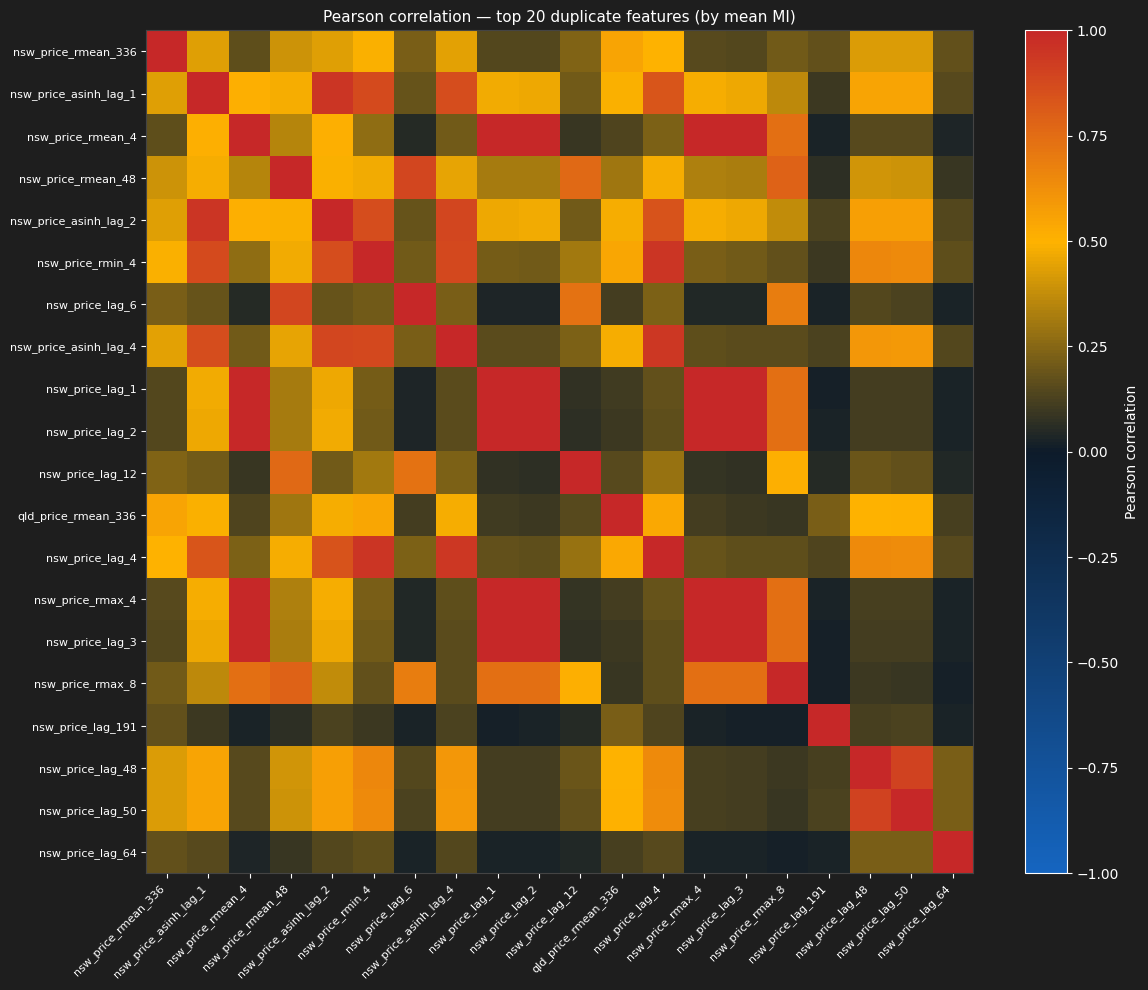

In [8]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
feature_data_flagged = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
features_subsampled = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_features_subsampled_{_stem}.parquet")
)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

TOP_N = 20

# Top N duplicate features by mean MI (highest MI duplicates — most "interesting" redundancies)
duplicate_features = (
    feature_data_flagged[feature_data_flagged["is_duplicate"] == True]
    .head(TOP_N)["feature"]
    .tolist()
)
top_features = [f for f in duplicate_features if f in features_subsampled.columns]
corr = features_subsampled[top_features].corr(method="pearson")

# Diverging colormap with accent at 75th percentile (0.5 on the -1→1 scale = position 0.75)
# blue → navy (mid) → electric cyan accent → crimson
_cmap = LinearSegmentedColormap.from_list(
    "dark_div_accent",
    [
        (0.00, "#1565C0"),   # -1.0  deep blue
        (0.50, "#0D1B2A"),   #  0.0  dark navy (midpoint)
        (0.75, "#FFB300"),   # +0.5  electric cyan accent (75th percentile)
        (1.00, "#C62828"),   # +1.0  deep crimson
    ],
)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(12, 10), facecolor="#1e1e1e")
    ax.set_facecolor("#1e1e1e")
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap=_cmap, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, label="Pearson correlation")
    cbar.ax.yaxis.label.set_color("white")
    cbar.ax.tick_params(colors="white")
    ax.set_xticks(range(len(top_features)))
    ax.set_yticks(range(len(top_features)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8, color="white")
    ax.set_yticklabels(corr.index, fontsize=8, color="white")
    ax.set_title(f"Pearson correlation — top {len(top_features)} duplicate features (by mean MI)", fontsize=11, color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    plt.tight_layout()
    plt.show()


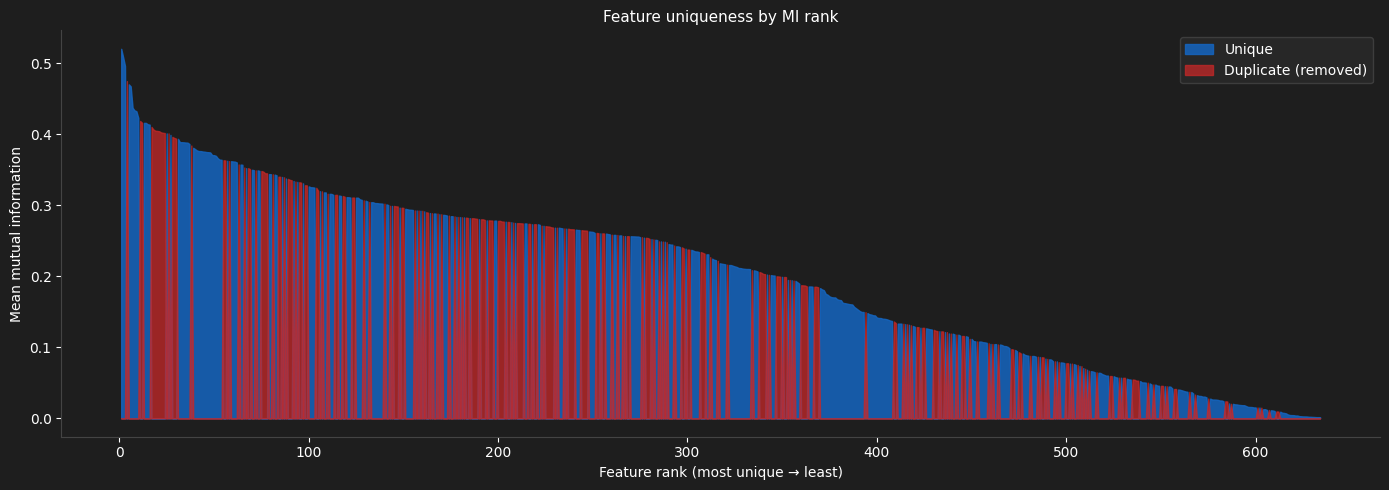

In [9]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
feature_data_flagged = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)

import matplotlib.pyplot as plt

df_plot = feature_data_flagged.sort_values("mean_mi", ascending=False).reset_index(drop=True)
df_plot["rank_pos"] = range(1, len(df_plot) + 1)

unique_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == False, 0)
dup_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == True, 0)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 5), facecolor="#1e1e1e")
    ax.set_facecolor("#1e1e1e")

    ax.fill_between(df_plot["rank_pos"], unique_mi, alpha=0.85, color="#1565C0", label="Unique")
    ax.fill_between(df_plot["rank_pos"], dup_mi, alpha=0.75, color="#C62828", label="Duplicate (removed)")

    ax.set_xlabel("Feature rank (most unique → least)", color="white", fontsize=10)
    ax.set_ylabel("Mean mutual information", color="white", fontsize=10)
    ax.set_title("Feature uniqueness by MI rank", fontsize=11, color="white")
    ax.tick_params(colors="white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_edgecolor("#444444")
    ax.spines["left"].set_edgecolor("#444444")
    ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="white")
    plt.tight_layout()
    plt.show()
